# 01 -- Exploratory Data Analysis

**Purpose:** profile *every single column* of `raw_employee_data` -- type, missingness,
distribution, and (for the target) class balance. This notebook is what satisfies
success metric #1 of the initiation document: *"100% of variables mapped"*.

**Prerequisites:** `docker compose up -d` and `python etl/load_raw.py` have both been run.

**Read this notebook top to bottom.** Section 10 lists the concrete decisions that
`etl/clean.py` and `ml/features.py` implement -- if you only read one section, read that one.

In [1]:
import sys, json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text

# Make `import db` work from inside notebooks/
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from db import get_engine

pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110

engine = get_engine()
TABLE = "raw_employee_data"

with engine.connect() as conn:
    N_ROWS = conn.execute(text(f"SELECT COUNT(*) FROM {TABLE}")).scalar_one()
print(f"{TABLE}: {N_ROWS:,} rows")

raw_employee_data: 849,999 rows


## 1. Column inventory

Every column, as Postgres sees it. Nothing is skipped -- the list below *is* the map of variables.

In [2]:
with engine.connect() as conn:
    inventory = pd.read_sql(text("""
        SELECT ordinal_position AS pos, column_name, data_type
        FROM information_schema.columns
        WHERE table_name = :t
        ORDER BY ordinal_position
    """), conn, params={"t": TABLE})

# Group the columns by the kind of analysis each one needs.
NUMERIC  = inventory.loc[inventory.data_type.isin(["double precision", "bigint"]), "column_name"].tolist()
NUMERIC  = [col for col in NUMERIC if col != "employee_id"]
BOOLEAN  = inventory.loc[inventory.data_type == "boolean", "column_name"].tolist()
JSONCOLS = inventory.loc[inventory.data_type == "jsonb", "column_name"].tolist()
TEXTCOLS = inventory.loc[inventory.data_type == "text", "column_name"].tolist()

# Long free-text needs different treatment from short category labels.
FREETEXT    = ["recent_feedback"]
CATEGORICAL = [col for col in TEXTCOLS if col not in FREETEXT]

print(f"{len(inventory)} columns total")
print(f"  numeric      ({len(NUMERIC)}): {NUMERIC}")
print(f"  boolean      ({len(BOOLEAN)}): {BOOLEAN}")
print(f"  json arrays  ({len(JSONCOLS)}): {JSONCOLS}")
print(f"  categorical  ({len(CATEGORICAL)}): {CATEGORICAL}")
print(f"  free text    ({len(FREETEXT)}): {FREETEXT}")
inventory

32 columns total
  numeric      (19): ['tenure_months', 'salary', 'performance_score', 'satisfaction_score', 'workload_score', 'team_sentiment', 'project_completion_rate', 'overtime_hours', 'training_participation', 'collaboration_score', 'email_sentiment', 'slack_activity', 'meeting_participation', 'goal_achievement_rate', 'stress_level', 'burnout_risk', 'turnover_probability_generated', 'role_complexity_score', 'career_progression_score']
  boolean      (1): ['left_company']
  json arrays  (2): ['technical_skills', 'soft_skills']
  categorical  (8): ['source_employee_id', 'role', 'job_level', 'department', 'communication_patterns', 'turnover_reason', 'risk_factors_summary', 'persona_name']
  free text    (1): ['recent_feedback']


,pos,column_name,data_type
0,1,employee_id,integer
1,2,source_employee_id,text
2,3,role,text
3,4,job_level,text
4,5,department,text
5,6,tenure_months,bigint
6,7,salary,double precision
7,8,performance_score,double precision
8,9,satisfaction_score,double precision
9,10,workload_score,double precision


## 2. Missingness -- and the kind of "missing" that hides from `IS NULL`

Two different checks, because they catch different problems:

1. **NULL** -- absent values.
2. **Blank / whitespace-only strings** -- present in the file, but carrying no information.
   These pass every `NOT NULL` check while being just as useless as a NULL, so we count them
   separately.

In [3]:
# Build one big query so we scan the 850k-row table only once.
select_parts = []
for col in inventory.column_name:
    select_parts.append(f'SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS "null__{col}"')
for col in CATEGORICAL + FREETEXT:
    select_parts.append(f'SUM(CASE WHEN TRIM("{col}") = \'\' THEN 1 ELSE 0 END) AS "blank__{col}"')
    select_parts.append(f'SUM(CASE WHEN "{col}" <> TRIM("{col}") THEN 1 ELSE 0 END) AS "untrim__{col}"')

with engine.connect() as conn:
    counts = conn.execute(text("SELECT " + ", ".join(select_parts) + f" FROM {TABLE}")).mappings().one()

rows = []
for col in inventory.column_name:
    n_null   = counts[f"null__{col}"]
    n_blank  = counts.get(f"blank__{col}", 0) or 0
    n_untrim = counts.get(f"untrim__{col}", 0) or 0
    rows.append({
        "column": col,
        "null_count": n_null,
        "null_pct": 100 * n_null / N_ROWS,
        "blank_count": n_blank,
        "blank_pct": 100 * n_blank / N_ROWS,
        "untrimmed_count": n_untrim,      # values with stray leading/trailing whitespace
    })

missing = pd.DataFrame(rows)
print(f"Columns containing NULLs: {(missing.null_count > 0).sum()}")
print(f"Columns containing blank/whitespace-only values: {(missing.blank_count > 0).sum()}")
missing

Columns containing NULLs: 0
Columns containing blank/whitespace-only values: 1


,column,null_count,null_pct,blank_count,blank_pct,untrimmed_count
0,employee_id,0,0.0000,0,0.0000,0
1,source_employee_id,0,0.0000,0,0.0000,0
2,role,0,0.0000,109047,12.8291,781698
3,job_level,0,0.0000,0,0.0000,0
4,department,0,0.0000,0,0.0000,13326
5,tenure_months,0,0.0000,0,0.0000,0
6,salary,0,0.0000,0,0.0000,0
7,performance_score,0,0.0000,0,0.0000,0
8,satisfaction_score,0,0.0000,0,0.0000,0
9,workload_score,0,0.0000,0,0.0000,0


> **Finding 1 -- there are no NULLs anywhere, but `role` is 12.8% blank.**
>
> The success metric "0% NULL values" is therefore already satisfied by the raw table, which
> makes it a weak check on its own. The *real* data-quality problem is whitespace:
> `role` is whitespace-only in ~109k rows and ~92% of all `role` values carry a stray leading
> space (so `" Data Analyst"` and `"Data Analyst"` are two different categories as far as any
> encoder is concerned). `clean.py` trims first, then treats blank as genuinely missing.

## 3. Numeric columns -- full distribution

Percentiles are computed over all 850k rows in Postgres (not on a sample), so these are exact.

In [4]:
stats_rows = []
for col in NUMERIC:
    with engine.connect() as conn:
        r = conn.execute(text(f"""
            SELECT MIN("{col}") AS min, MAX("{col}") AS max,
                   AVG("{col}") AS mean, STDDEV("{col}") AS std,
                   percentile_cont(0.01) WITHIN GROUP (ORDER BY "{col}") AS p01,
                   percentile_cont(0.25) WITHIN GROUP (ORDER BY "{col}") AS p25,
                   percentile_cont(0.50) WITHIN GROUP (ORDER BY "{col}") AS median,
                   percentile_cont(0.75) WITHIN GROUP (ORDER BY "{col}") AS p75,
                   percentile_cont(0.99) WITHIN GROUP (ORDER BY "{col}") AS p99,
                   COUNT(DISTINCT "{col}") AS n_distinct,
                   SUM(CASE WHEN "{col}" = 0 THEN 1 ELSE 0 END) AS n_zero
            FROM {TABLE}
        """)).mappings().one()
    stats_rows.append({"column": col, **{k: float(v) if v is not None else None for k, v in r.items()}})

numeric_profile = pd.DataFrame(stats_rows).set_index("column")
numeric_profile["zero_pct"] = 100 * numeric_profile["n_zero"] / N_ROWS
numeric_profile

,min,max,mean,std,p01,p25,median,p75,p99,n_distinct,n_zero,zero_pct
column,,,,,,,,,,,,
tenure_months,1.0000,357.0000,70.3810,50.1770,1.0000,30.0000,67.0000,105.0000,197.0000,309.0000,0.0000,0.0000
salary,"27,190.5693","384,330.4287","84,563.0698","47,444.3086","29,025.6508","41,006.7770","78,178.5259","116,146.6396","212,778.1249","849,999.0000",0.0000,0.0000
performance_score,0.0741,1.0000,0.6920,0.1839,0.2628,0.5713,0.6992,0.8256,1.0000,"789,100.0000",0.0000,0.0000
satisfaction_score,0.0500,1.0000,0.5819,0.2763,0.0500,0.3670,0.5832,0.8139,1.0000,"789,548.0000",0.0000,0.0000
workload_score,0.0067,0.9996,0.5995,0.2000,0.1413,0.4557,0.6137,0.7567,0.9582,"849,999.0000",0.0000,0.0000
team_sentiment,0.0198,1.0000,0.6668,0.1782,0.2230,0.5457,0.6863,0.8065,0.9674,"849,999.0000",0.0000,0.0000
project_completion_rate,0.0593,1.0000,0.5954,0.1612,0.2268,0.4902,0.6095,0.7161,0.9020,"817,159.0000",0.0000,0.0000
overtime_hours,0.0000,73.9536,3.1329,6.0942,0.0000,0.0000,0.0000,4.1612,26.4158,"266,293.0000","583,707.0000",68.6715
training_participation,0.0001,1.0000,0.2793,0.2216,0.0121,0.1037,0.2231,0.4007,0.9787,"842,938.0000",0.0000,0.0000


Plotting sample: 106,249 rows


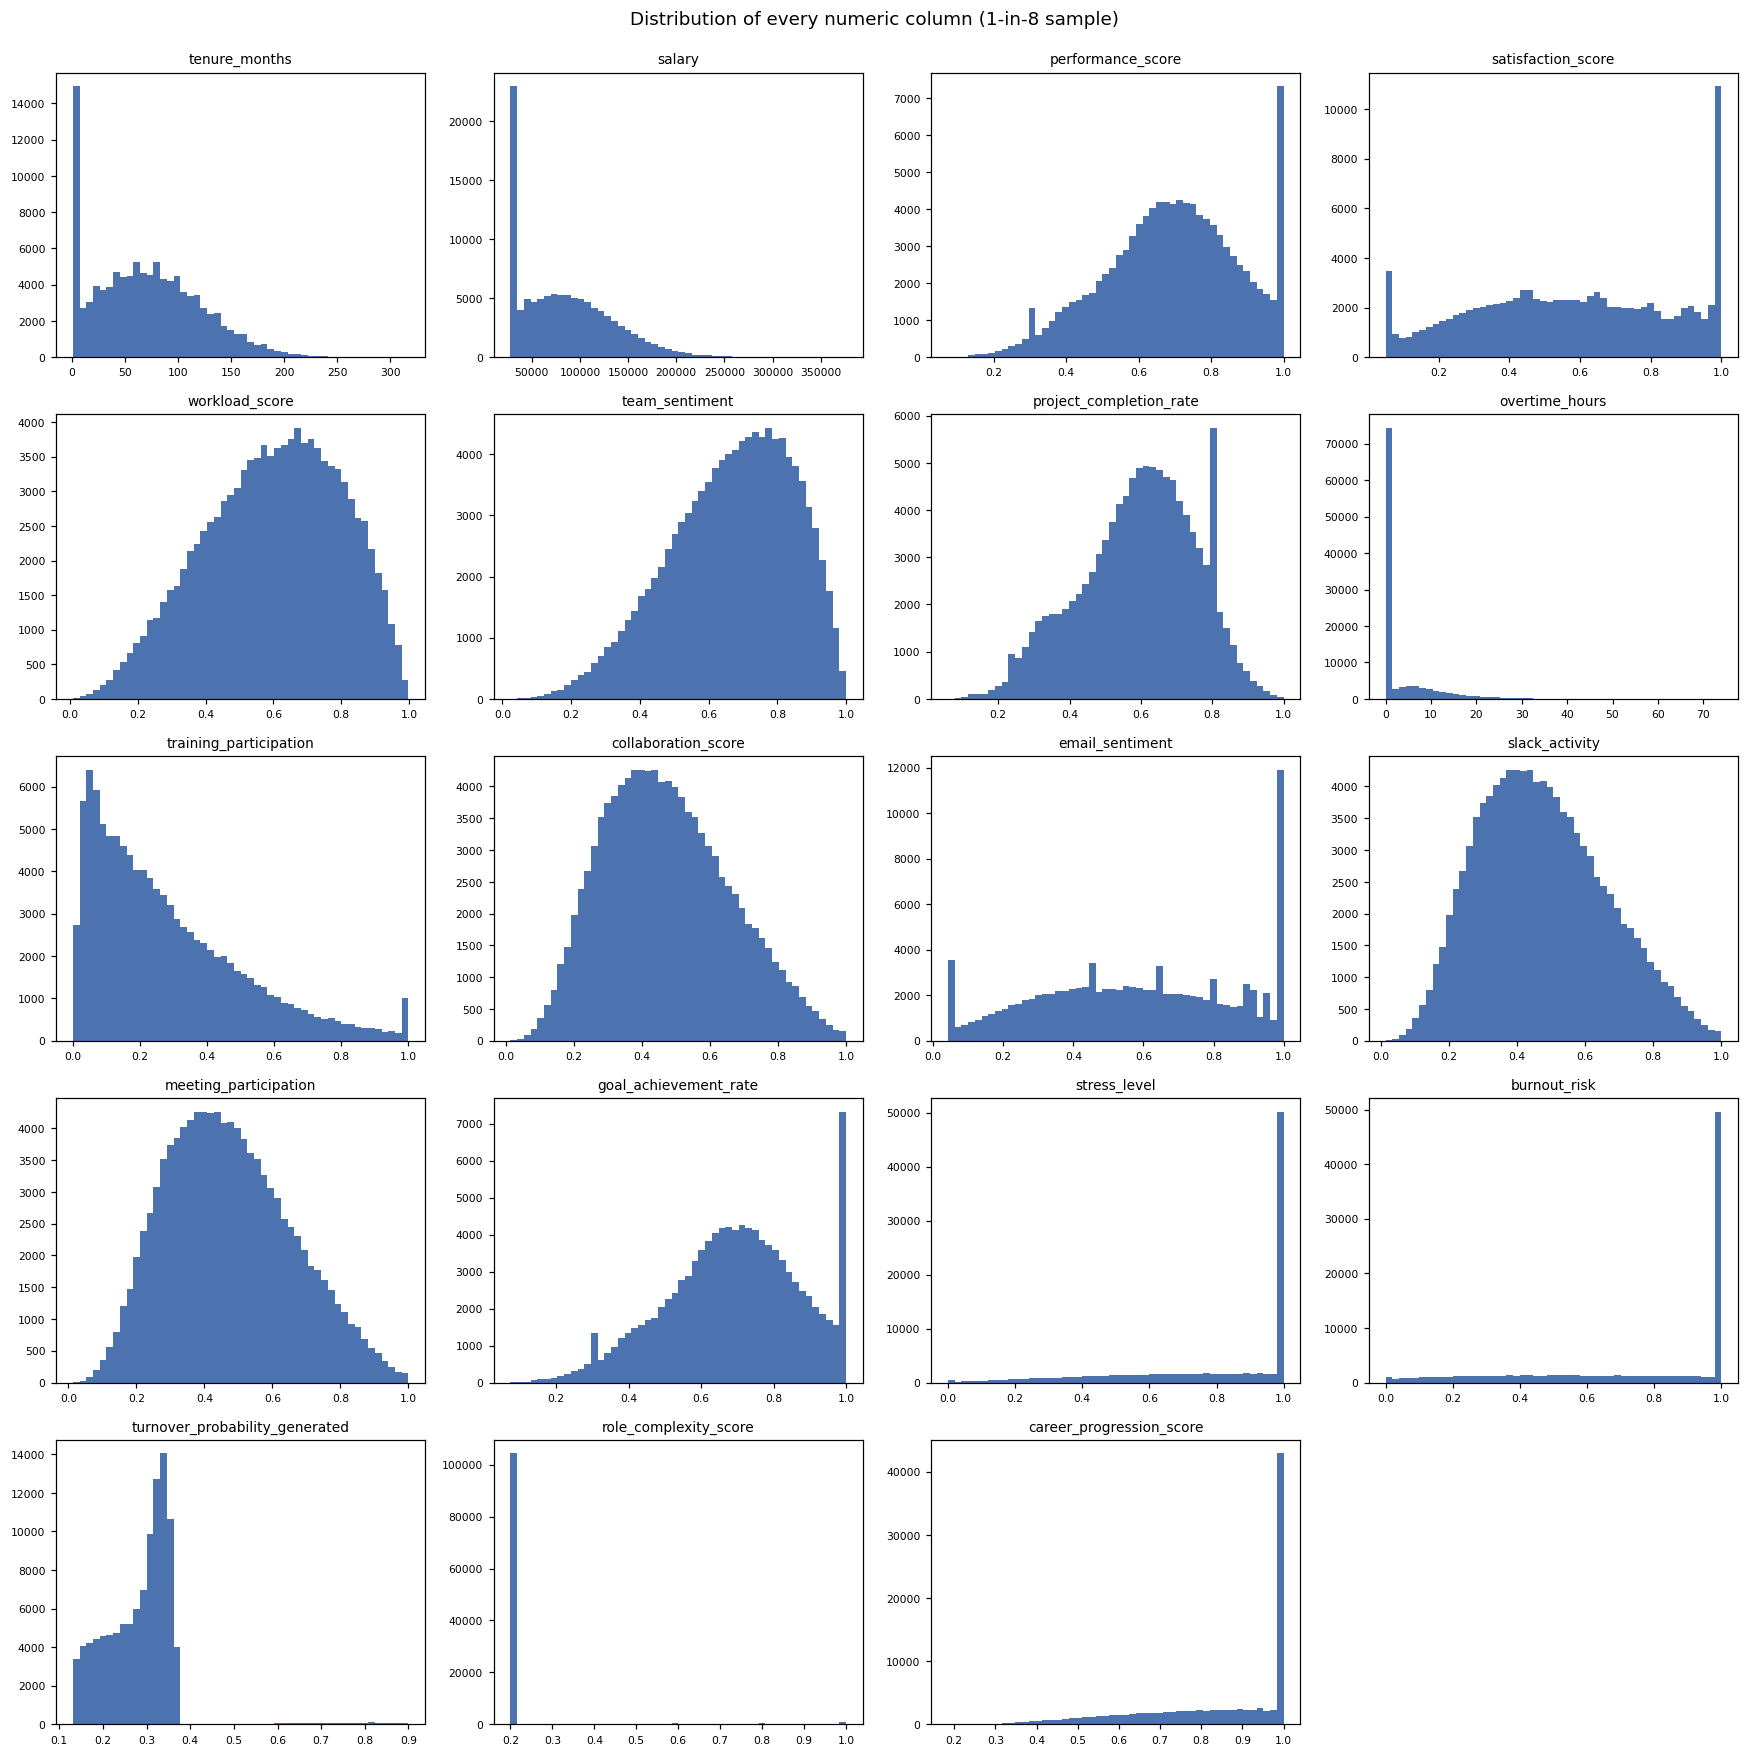

In [5]:
# Pull a deterministic 1-in-8 sample (~106k rows) for plotting. Deterministic so that
# re-running the notebook gives the same pictures.
with engine.connect() as conn:
    sample = pd.read_sql(
        text(f'SELECT * FROM {TABLE} WHERE MOD(employee_id, 8) = 0'), conn
    )
print(f"Plotting sample: {len(sample):,} rows")

fig, axes = plt.subplots(5, 4, figsize=(16, 16))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.hist(sample[col].dropna(), bins=50, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(NUMERIC):]:
    ax.axis("off")
fig.suptitle("Distribution of every numeric column (1-in-8 sample)", y=0.995)
fig.tight_layout()
plt.show()

## 4. Categorical columns

Cardinality plus the most common values. `role` has ~300 raw levels, most of which are
whitespace variants of the same job title -- see the trimmed count below.

In [6]:
for col in CATEGORICAL + BOOLEAN:
    with engine.connect() as conn:
        n_distinct = conn.execute(text(f'SELECT COUNT(DISTINCT "{col}") FROM {TABLE}')).scalar_one()
        if col in CATEGORICAL:
            n_trimmed = conn.execute(
                text(f'SELECT COUNT(DISTINCT TRIM("{col}")) FROM {TABLE}')
            ).scalar_one()
        else:
            n_trimmed = n_distinct
        top = pd.read_sql(text(f"""
            SELECT "{col}"::text AS value, COUNT(*) AS n,
                   ROUND(100.0 * COUNT(*) / {N_ROWS}, 2) AS pct
            FROM {TABLE} GROUP BY 1 ORDER BY n DESC LIMIT 10
        """), conn)
    note = "" if n_distinct == n_trimmed else f"  -> {n_trimmed} after TRIM()"
    print(f"\n=== {col} -- {n_distinct} distinct{note} ===")
    print(top.to_string(index=False))


=== source_employee_id -- 849999 distinct ===
       value  n    pct
SYN_00193960  1 0.0000
SYN_00182540  1 0.0000
SYN_00176705  1 0.0000
SYN_00138904  1 0.0000
SYN_00130618  1 0.0000
SYN_00199615  1 0.0000
SYN_00177409  1 0.0000
SYN_00149531  1 0.0000
SYN_00166650  1 0.0000
SYN_00150710  1 0.0000



=== role -- 300 distinct  -> 289 after TRIM() ===
                                value      n     pct
                   Anonymous Employee 224117 26.3700
                                      109047 12.8300
Current Employee - Anonymous Employee  21989  2.5900
                              Manager  20440  2.4000
                           Consultant  17308  2.0400
                    Software Engineer  14957  1.7600
 Former Employee - Anonymous Employee  14467  1.7000
                            Associate  14152  1.6600
                    Senior Consultant  14047  1.6500
                              Analyst  13446  1.5800



=== job_level -- 5 distinct ===
  value      n     pct
    Mid 609887 71.7500
  Entry 101211 11.9100
Manager  78219  9.2000
 Senior  41347  4.8600
   Lead  19335  2.2700



=== department -- 38 distinct ===
                 value      n     pct
     Sales & Marketing 155390 18.2800
Research & Development 101963 12.0000
            Operations 101176 11.9000
            Technology  64037  7.5300
           Procurement  63979  7.5300
             Analytics  49011  5.7700
                 Sales  48980  5.7600
      Customer Service  36774  4.3300
                 Meats  32376  3.8100
                 Dairy  32370  3.8100



=== communication_patterns -- 12 distinct ===
                                                                   value     n     pct
    Exhibits communication style typical of a StrugglingLearner persona. 86714 10.2000
   Exhibits communication style typical of a CorporateNavigator persona. 69639  8.1900
           Exhibits communication style typical of a SteadyEddy persona. 69611  8.1900
        Exhibits communication style typical of a NewEnthusiast persona. 69566  8.1800
        Exhibits communication style typical of a QuietAchiever persona. 69525  8.1800
   Exhibits communication style typical of a 9-to-5Clockwatcher persona. 69434  8.1700
       Exhibits communication style typical of a ChangeResistor persona. 69337  8.1600
       Exhibits communication style typical of a SeasonedExpert persona. 69293  8.1500
       Exhibits communication style typical of a SocialCatalyst persona. 69273  8.1500
Exhibits communication style typical of a OverachievingSprinter persona. 69243  8.1


=== turnover_reason -- 7 distinct ===
                              value      n     pct
                     Not Applicable 604246 71.0900
        Burnout / Work-Life Balance 107739 12.6800
              Personal / Relocation  74178  8.7300
Compensation / Role Dissatisfaction  34664  4.0800
         Personal Reasons (Anomaly)  12750  1.5000
          Involuntary (Performance)   8896  1.0500
                 Career Opportunity   7526  0.8900



=== risk_factors_summary -- 6 distinct ===
                                 value      n     pct
                   Severe Burnout Risk 489520 57.5900
                              Low Risk 315695 37.1400
     Anomaly: Overpaid/Underperforming  17000  2.0000
                      Low Satisfaction  13207  1.5500
Anomaly: High Satisfaction Flight Risk  12493  1.4700
                       Low Performance   2084  0.2500



=== persona_name -- 12 distinct ===
                value     n     pct
    StrugglingLearner 86714 10.2000
   CorporateNavigator 69639  8.1900
           SteadyEddy 69611  8.1900
        NewEnthusiast 69566  8.1800
        QuietAchiever 69525  8.1800
   9-to-5Clockwatcher 69434  8.1700
       ChangeResistor 69337  8.1600
       SeasonedExpert 69293  8.1500
       SocialCatalyst 69273  8.1500
OverachievingSprinter 69243  8.1500



=== left_company -- 2 distinct ===
value      n     pct
false 607473 71.4700
 true 242526 28.5300


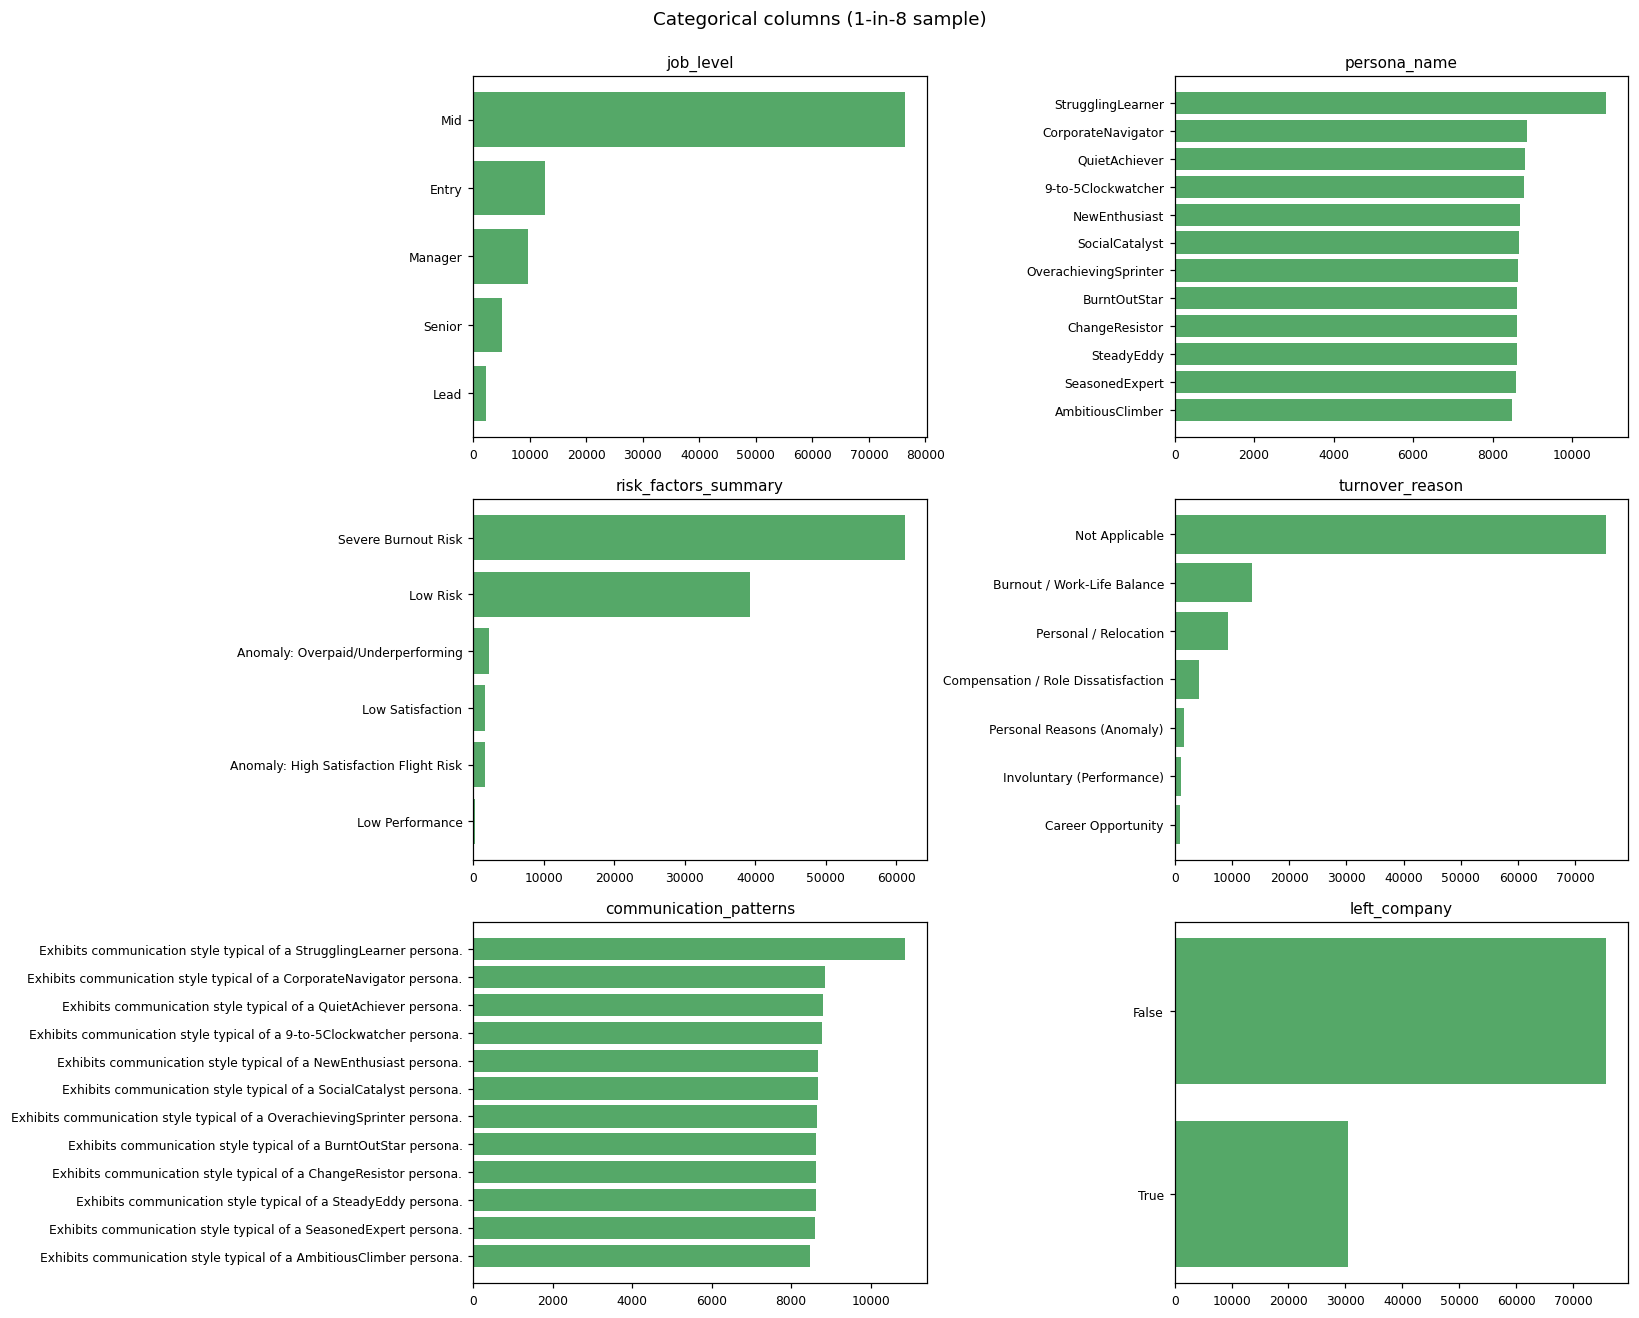

In [7]:
# Bar charts for the columns with few enough levels to read.
plot_cats = ["job_level", "persona_name", "risk_factors_summary", "turnover_reason",
             "communication_patterns", "left_company"]
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for ax, col in zip(axes.ravel(), plot_cats):
    counts = sample[col].astype(str).str.strip().value_counts().head(12)
    ax.barh(counts.index[::-1], counts.values[::-1], color="#55A868")
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("Categorical columns (1-in-8 sample)", y=0.995)
fig.tight_layout()
plt.show()

## 5. The two JSON array columns

`technical_skills` and `soft_skills` are lists. A model cannot consume a list directly, so
section 10 records how they get turned into numbers.

In [8]:
for col in JSONCOLS:
    with engine.connect() as conn:
        lengths = pd.read_sql(text(f"""
            SELECT jsonb_array_length("{col}") AS n_items, COUNT(*) AS n_employees
            FROM {TABLE} GROUP BY 1 ORDER BY 1
        """), conn)
        top_items = pd.read_sql(text(f"""
            SELECT item, COUNT(*) AS n
            FROM {TABLE}, jsonb_array_elements_text("{col}") AS item
            GROUP BY 1 ORDER BY n DESC LIMIT 15
        """), conn)
    print(f"\n=== {col}: list length distribution ===")
    print(lengths.to_string(index=False))
    print(f"--- most common entries ---")
    print(top_items.to_string(index=False))


=== technical_skills: list length distribution ===
 n_items  n_employees
       4       141492
       5       141806
       6       142199
       7       141026
       8       141891
       9       141585
--- most common entries ---
                                            item      n
                                           HTML5 113341
                                          Docker 113336
                                             SQL 113332
             Deep Learning (TensorFlow, PyTorch) 113247
Data Warehousing (Snowflake, BigQuery, Redshift) 113137
                              Java (Spring Boot) 112987
                                    Apache Kafka 112986
                                     A/B Testing 112986
                   Python (Pandas, NumPy, SciPy) 112962
                                 CI/CD Pipelines 112957
              Site Reliability Engineering (SRE) 112949
                                            CSS3 112947
                                      


=== soft_skills: list length distribution ===
 n_items  n_employees
       3       169496
       4       170022
       5       170067
       6       169999
       7       170415
--- most common entries ---
                  item      n
       Problem Solving 387189
Emotional Intelligence 387090
   Conflict Resolution 386827
         Communication 386671
            Creativity 386565
            Mentorship 386510
     Critical Thinking 386466
       Time Management 386300
              Teamwork 386242
            Leadership 386046
          Adaptability 385904


## 6. Free-text columns

`recent_feedback` is real prose (scraped-looking review text). `communication_patterns` looks
like free text but is actually a 12-value template keyed off `persona_name` -- section 9 shows
why that matters.

In [9]:
with engine.connect() as conn:
    text_stats = pd.read_sql(text(f"""
        SELECT
            MIN(LENGTH(recent_feedback)) AS min_len,
            AVG(LENGTH(recent_feedback)) AS mean_len,
            MAX(LENGTH(recent_feedback)) AS max_len,
            COUNT(DISTINCT recent_feedback) AS n_distinct
        FROM {TABLE}
    """), conn)
print("recent_feedback length profile:")
print(text_stats.to_string(index=False))

print("\n--- three example values ---")
for value in sample["recent_feedback"].head(3):
    print(" *", value[:220].replace("\r\n", " / "), "...")

print("\n--- communication_patterns: all distinct values ---")
with engine.connect() as conn:
    print(pd.read_sql(text(f'SELECT DISTINCT communication_patterns FROM {TABLE}'), conn).to_string(index=False))

recent_feedback length profile:
 min_len  mean_len  max_len  n_distinct
      49  209.4308      609        1000

--- three example values ---
 * Great Benefits, Lots of Travel Great place to start your career. Unlimited PTO is pointless if you can’t use the tile or it’s frowned upon which it is. But with great new hires they're working on making a difference. ...
 * Excellent Starting Point and Career Experience Amat offers a veryCompetitive salary Great Work environment, colleagues and opportunities ...
 * Increments appraisal system variable pay The discount sucks, and it’s very clique-y Review process allows for significant anonymous backstabbing & blame storming in times of declining defense bugets leading to a continuo ...

--- communication_patterns: all distinct values ---
                                                  communication_patterns
   Exhibits communication style typical of a 9-to-5Clockwatcher persona.
     Exhibits communication style typical of a AmbitiousClimber

## 7. The target variable

The dataset ships **no ready-made binary label**. What it has is `burnout_risk`, a continuous
0-1 score, plus `risk_factors_summary`, a text tier. The cell below shows how they relate --
and it turns out `risk_factors_summary` is just `burnout_risk` cut at **0.75**.

That gives us a principled, non-arbitrary threshold: we adopt the dataset's own definition of
"Severe Burnout Risk" as the positive class.

In [10]:
with engine.connect() as conn:
    tier_vs_score = pd.read_sql(text(f"""
        SELECT risk_factors_summary,
               COUNT(*) AS n,
               MIN(burnout_risk) AS min_risk,
               MAX(burnout_risk) AS max_risk,
               AVG(burnout_risk) AS mean_risk
        FROM {TABLE} GROUP BY 1 ORDER BY n DESC
    """), conn)
print("risk_factors_summary vs burnout_risk -- note where the two main tiers split:")
print(tier_vs_score.to_string(index=False))

# Class balance at a range of candidate cut-offs.
rows = []
for threshold in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    with engine.connect() as conn:
        n_pos = conn.execute(
            text(f"SELECT COUNT(*) FROM {TABLE} WHERE burnout_risk >= {threshold}")
        ).scalar_one()
    rows.append({"threshold": threshold, "n_positive": n_pos, "positive_pct": 100 * n_pos / N_ROWS})
print("\nClass balance at candidate thresholds:")
print(pd.DataFrame(rows).to_string(index=False))

risk_factors_summary vs burnout_risk -- note where the two main tiers split:
                  risk_factors_summary      n  min_risk  max_risk  mean_risk
                   Severe Burnout Risk 489520    0.7500    1.0000     0.9713
                              Low Risk 315695    0.0000    0.7500     0.3917
     Anomaly: Overpaid/Underperforming  17000    0.0000    1.0000     0.7351
                      Low Satisfaction  13207    0.2690    0.7500     0.6142
Anomaly: High Satisfaction Flight Risk  12493    0.0000    1.0000     0.3960
                       Low Performance   2084    0.0000    0.7490     0.4060



Class balance at candidate thresholds:
 threshold  n_positive  positive_pct
    0.5000      627195       73.7877
    0.6000      575587       67.7162
    0.7000      525642       61.8403
    0.7500      501327       58.9797
    0.8000      477547       56.1821
    0.9000      431535       50.7689
    0.9500      409499       48.1764


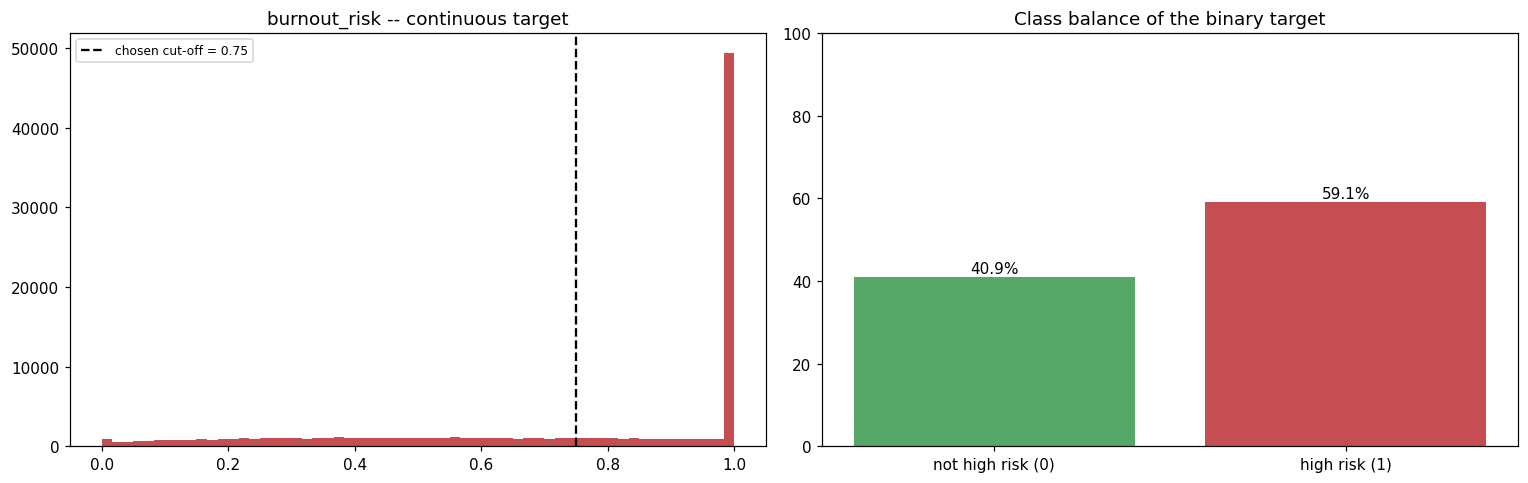

Positive class (high burnout risk): 59.09% of employees


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(sample["burnout_risk"], bins=60, color="#C44E52")
axes[0].axvline(0.75, color="black", ls="--", label="chosen cut-off = 0.75")
axes[0].set_title("burnout_risk -- continuous target")
axes[0].legend(fontsize=8)

target = (sample["burnout_risk"] >= 0.75).astype(int)
balance = target.value_counts(normalize=True).sort_index() * 100
axes[1].bar(["not high risk (0)", "high risk (1)"], balance.values, color=["#55A868", "#C44E52"])
for i, v in enumerate(balance.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center")
axes[1].set_ylim(0, 100)
axes[1].set_title("Class balance of the binary target")
fig.tight_layout()
plt.show()

print(f"Positive class (high burnout risk): {balance.get(1, 0):.2f}% of employees")

> **Finding 2 -- the target is a *majority* class, not a rare event.**
>
> 59% of employees fall in the positive class. The acceptance bar in the build spec
> (Recall >= 90%, Precision >= 15%) was written for a rare positive class -- here a model that
> blindly predicts "everyone is at risk" scores 100% recall and 59% precision and clears the
> bar without learning anything. `ml/evaluate.py` therefore scores that trivial baseline
> explicitly alongside the real models, so the comparison stays honest.

## 8. Duplicate columns

Before trusting 31 features, check that they *are* 31 features. We test every numeric pair for
exact equality on the sample, then confirm any hits against all 850k rows.

In [12]:
candidates = []
for i, a in enumerate(NUMERIC):
    for b in NUMERIC[i + 1:]:
        if sample[a].equals(sample[b]):
            candidates.append((a, b))

print(f"Identical pairs in the sample: {len(candidates)}")
for a, b in candidates:
    with engine.connect() as conn:
        n_diff = conn.execute(
            text(f'SELECT COUNT(*) FROM {TABLE} WHERE "{a}" IS DISTINCT FROM "{b}"')
        ).scalar_one()
    verdict = "IDENTICAL across all rows" if n_diff == 0 else f"{n_diff:,} rows differ"
    print(f"  {a} == {b}: {verdict}")

Identical pairs in the sample: 4


  performance_score == goal_achievement_rate: IDENTICAL across all rows
  collaboration_score == slack_activity: IDENTICAL across all rows


  collaboration_score == meeting_participation: IDENTICAL across all rows


  slack_activity == meeting_participation: IDENTICAL across all rows


> **Finding 3 -- five columns are really three.**
>
> `collaboration_score`, `slack_activity` and `meeting_participation` hold byte-identical
> values in all 849,999 rows, as do `performance_score` and `goal_achievement_rate`. They are
> not correlated-but-distinct signals; they are the same column copied. `clean.py` keeps one of
> each and drops the copies -- that is the "dedup" requirement, applied to columns rather than
> to rows (there are no duplicate rows: `source_employee_id` is unique).

## 9. Leakage screen

This is a *synthetic* dataset: rows were generated from a persona, and several columns are
by-products of that generator rather than things an HR system would observe. Any of them used
as a feature would leak the answer.

In [13]:
target_col = "burnout_risk"
corrs = []
for col in NUMERIC:
    if col == target_col:
        continue
    with engine.connect() as conn:
        r = conn.execute(text(f'SELECT CORR("{col}", {target_col}) FROM {TABLE}')).scalar_one()
    corrs.append({"column": col, "corr_with_burnout_risk": float(r)})

corr_table = pd.DataFrame(corrs).sort_values("corr_with_burnout_risk", key=abs, ascending=False)
corr_table["leakage_suspect"] = corr_table.corr_with_burnout_risk.abs() > 0.9
print(corr_table.to_string(index=False))

with engine.connect() as conn:
    n_same = conn.execute(text(
        f"SELECT COUNT(*) FROM {TABLE} WHERE ABS(burnout_risk - stress_level) < 1e-9"
    )).scalar_one()
print(f"\nstress_level is *exactly* equal to burnout_risk in {n_same:,} rows "
      f"({100 * n_same / N_ROWS:.1f}%) -- it is a copy of the target, not a predictor.")

                        column  corr_with_burnout_risk  leakage_suspect
                  stress_level                  0.9942             True
               email_sentiment                 -0.6763            False
            satisfaction_score                 -0.6753            False
turnover_probability_generated                  0.5929            False
                slack_activity                 -0.4716            False
           collaboration_score                 -0.4716            False
         meeting_participation                 -0.4716            False
       project_completion_rate                 -0.4234            False
                workload_score                 -0.4035            False
                overtime_hours                  0.2410            False
             performance_score                 -0.1063            False
         goal_achievement_rate                 -0.1063            False
        training_participation                  0.0722          

> **Finding 4 -- seven columns must be excluded from the feature set.**
>
> | Column | Why it leaks |
> |---|---|
> | `burnout_risk` | the target itself |
> | `stress_level` | r = 0.994 with the target, and *exactly equal* in 46% of rows |
> | `risk_factors_summary` | a text restatement of the target, cut at 0.75 |
> | `turnover_probability_generated` | generator internal (the name says so), r = 0.59 |
> | `persona_name` | the generator's latent class; every other column is drawn from it |
> | `communication_patterns` | a 12-value template keyed directly off `persona_name` |
> | `left_company`, `turnover_reason` | outcomes recorded *after* the fact -- not available at prediction time |
>
> Keeping any of these would produce a model with ~1.0 AUC that is useless in production.

## 10. Decisions carried into the rest of the pipeline

Everything above, condensed into what `clean.py`, `features.py` and `train.py` actually do:

**Cleaning (`etl/clean.py`)**
1. `TRIM()` every text column -- fixes ~782k stray-whitespace `role` values and 13k in `department`.
2. Blank-after-trim `role` becomes the explicit category `"Unknown"` (12.8% of rows) rather than
   a NULL, so the final table can hold 0 NULLs *honestly* instead of by deletion.
3. Drop the three duplicate columns: `slack_activity`, `meeting_participation`, `goal_achievement_rate`.
4. Replace the two JSON arrays with counts: `n_technical_skills`, `n_soft_skills`.
5. Derive `recent_feedback_length` from the free text, then drop the prose itself.
6. Add the binary target `is_high_burnout_risk = burnout_risk >= 0.75`.
7. Assert 0 NULLs and 0 out-of-range values before the table is accepted (success metric #2).

**Features (`ml/features.py`)**
- Exclude all seven leakage columns listed in Finding 4.
- One-hot `job_level`, `department`, `role` (top-N levels; the tail becomes "Other").
- Stratified 80/20 train/test split.

**Modelling (`ml/train.py`, `ml/evaluate.py`)**
- Logistic Regression, Random Forest and XGBoost, compared on the same test set.
- Score the trivial "predict everyone positive" baseline too, because the 59% base rate makes
  the spec's Recall/Precision bar clearable without learning anything.